## Embryo vs gastruloids marker lineplots

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pydeseq2.preprocessing import deseq2_norm

#### Load data

In [2]:
# embryo
embryo_pseudo = pd.read_excel('../data/pseudobulk/mouse_embryonic_pseudobulk_by_stage.xlsx', sheet_name='Sheet 1')
embryo_pseudo['gene_symbol'].replace('T','Tbxt', inplace=True)
embryo_pseudo = embryo_pseudo.set_index("gene_symbol")
embryo_pseudo.drop(columns='gene_ID', inplace=True)

# select timeframe from E6.5-E8.0
embryo_pseudo = embryo_pseudo[["E6.5","E6.75","E7.0","E7.25","E7.5","E7.75","E8.0"]]
embryo_pseudo.head()

/tmp/ipykernel_23893/3543638348.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  embryo_pseudo['gene_symbol'].replace('T','Tbxt', inplace=True)


,E6.5,E6.75,E7.0,E7.25,E7.5,E7.75,E8.0
gene_symbol,,,,,,,
Xkr4,2,0,7,6,9,17,7
Gm1992,0,0,0,0,0,0,0
Gm37381,0,0,0,0,0,0,0
Rp1,0,0,2,2,2,25,13
Sox17,19,88,5670,5585,4497,2914,3630


## embryo timecourse lineplot

In [3]:
genes = ['Eomes', 'Nodal', 'Wnt3', 'Fgf5', 'Utf1','Tbxt', 'Cdx2', 'Hoxa1', 'Hoxb1', 'Wnt3a']
genes_black = ['Gsc', 'Lhx1', 'Nanog', 'Cer1', 'Foxa2', 'Chrd'] + genes

In [4]:
palette_v1 = {
    "Fgf5": "#1f77b4",   # deep blue
    "Nodal": "#63a0cf",   # sky blue
    "Utf1": "#2ca02c",  # forest green
    "Eomes": "#66c266",  # lime green
    "Wnt3": "#98d698",   # light green
    "Tbxt": "#d62728",   # dark red
    "Hoxb1": "#ff6b6b",  # coral red
    "Cdx2": "#ff8c6d",   # salmon
    "Hoxa1": "#ffb399",  # peach
    "Wnt3a": "#ffd1cc"   # very light red/pink
}

palette_v2 = {
    # Greens (CB-friendly)
    "Eomes": "#009E73",    # dark green
    "Nodal": "#33B890",    # medium green
    "Wnt3":  "#66CCA9",    # light green
    "Fgf5":  "#99E0C3",    # pale green
    "Utf1":  "#CCEEDF",    # very pale green

    # Reds/Oranges (CB-friendly)
    "Tbxt":  "#D55E00",    # strong red-orange (safe)
    "Cdx2":  "#E78633",    # softer orange-red
    "Hoxa1": "#E69F00",    # golden orange
    "Hoxb1": "#F2B670",    # light warm red/orange
    "Wnt3a": "#F6D5B8"     # pale peach
}



In [5]:
# subset markers and lognormalze
df_scaled=deseq2_norm(embryo_pseudo.T)[0].T

#df_scaled =embryo_pseudo.div(embryo_pseudo.sum(axis=1), axis=0)*10E6
logdf = np.log1p(df_scaled)
logdf = logdf.loc[genes,:]

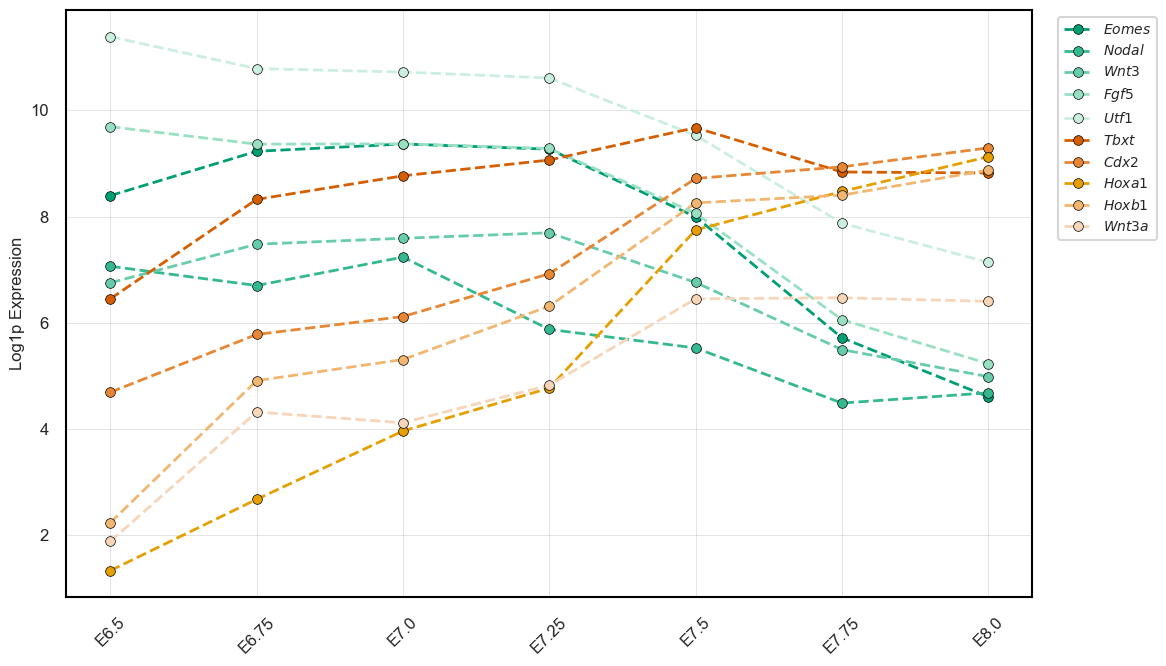

In [6]:
# construct lineplot v2
sns.set(style="whitegrid", context="talk")

plt.figure(figsize=(12, 7))
ax = plt.gca()
palette = palette_v2
for i, gene in enumerate(genes):
    plt.plot(
        logdf.columns,
        logdf.loc[gene],
        marker='o',
        markersize=7,
        markeredgecolor='black',
        markeredgewidth=0.5,
        linestyle='--',
        linewidth=2,
        color=palette[gene],
        label=f"${gene}$"  # Italic in legend using LaTeX math mode
    )

plt.grid(True, linewidth=0.5, color='gray', alpha=0.3)
plt.ylabel('Log1p Expression', fontsize=12)

plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True, fontsize=10)
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.5)
plt.tight_layout()
plt.savefig('../results/lineplot_embryo_pseudobulk_deseq2.svg', format='svg')
plt.show()

## gastruloid lineplot

In [7]:
# gastruloid
gastruloid_bulk = pd.read_csv('../data/wnt_nodal_rnaseq/chir_act_counts.csv', index_col=0)
gastruloid_bulk.index = gastruloid_bulk.index.str.replace('T', 'Tbxt')

df = gastruloid_bulk.filter(regex="48h_|60h-3μM-CHIR|72h-3μM-CHIR|96h-3μM-CHIR")


In [8]:
# subset markers and lognormalze
df_scaled=deseq2_norm(df.T)[0].T

#df_scaled = df.div(df.sum(axis=1), axis=0)*10E6
logdf = np.log1p(df_scaled)
logdf = logdf.loc[genes,:]


In [9]:
cond_names = [c.rsplit('_', 1)[0] for c in logdf.columns]

# Make a mapping from original columns to condition
col_map = dict(zip(logdf.columns, cond_names))

# Rename columns temporarily
logdf_ = logdf.rename(columns=col_map)

In [10]:
# Group by condition and calculate mean and std
mean_df = logdf_.groupby(level=0, axis=1).mean()
std_df  = logdf_.groupby(level=0, axis=1).std()


/tmp/ipykernel_23893/563452608.py:2: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  mean_df = logdf_.groupby(level=0, axis=1).mean()
/tmp/ipykernel_23893/563452608.py:3: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  std_df  = logdf_.groupby(level=0, axis=1).std()


In [11]:
mean_df = mean_df[['48h', '60h-3μM-CHIR', '72h-3μM-CHIR', '96h-3μM-CHIR']]
std_df = std_df[['48h', '60h-3μM-CHIR', '72h-3μM-CHIR', '96h-3μM-CHIR']]

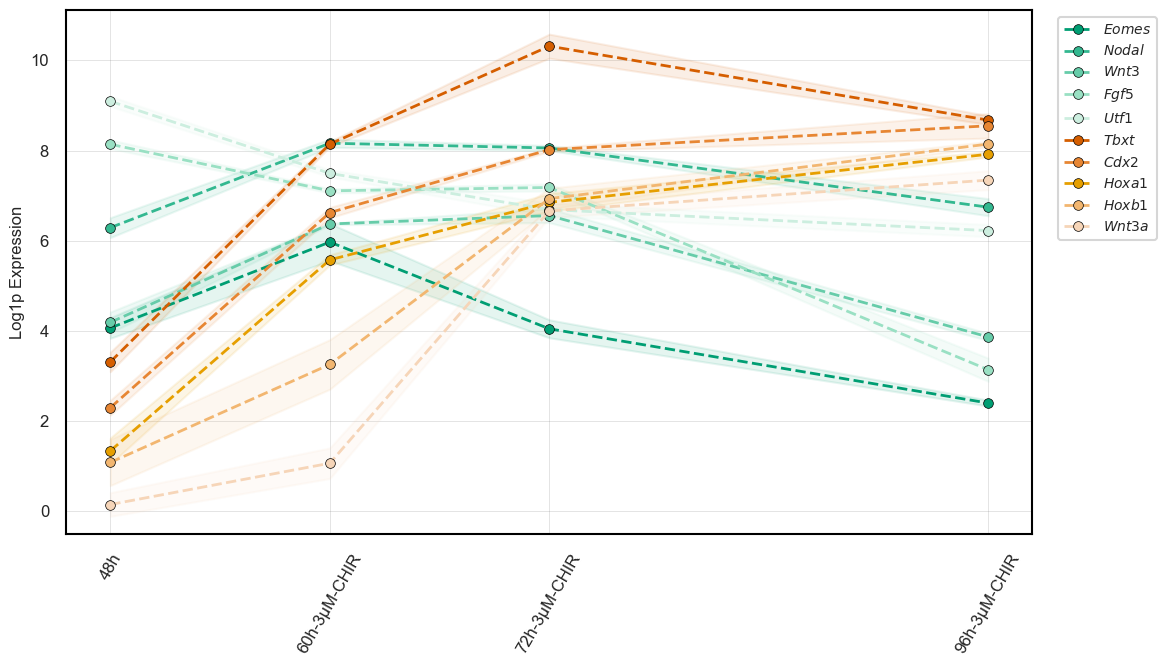

In [12]:
sns.set(style="whitegrid", context="talk")
plt.figure(figsize=(12, 7))
ax = plt.gca()

# real time positions
timepoints = np.array([48, 60, 72, 96])

palette = palette_v2

for gene in mean_df.index:
    plt.plot(
        timepoints,
        mean_df.loc[gene],
        marker='o',
        markersize=7,
        markeredgecolor='black',
        markeredgewidth=0.5,
        linestyle='--',
        linewidth=2,
        color=palette[gene],
        label=f"${gene}$"
    )

    plt.fill_between(
        timepoints,
        mean_df.loc[gene] - std_df.loc[gene],
        mean_df.loc[gene] + std_df.loc[gene],
        color=palette[gene],
        alpha=0.1
    )

ax.set_ylim(-0.5)
plt.ylabel("Log1p Expression", fontsize=12)

# proportional spacing but categorical labels
plt.xticks(timepoints, ['48h', '60h-3μM-CHIR', '72h-3μM-CHIR', '96h-3μM-CHIR'], fontsize=12, rotation=60)
plt.yticks(fontsize=12)

plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=10)
plt.grid(True, linewidth=0.5, color="gray", alpha=0.3)

for spine in ax.spines.values():
    spine.set_edgecolor("black")
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.savefig("../results/lineplot_gastruloid_v2.svg", format="svg")
plt.show()


## Wnt and Nodal reporters

In [13]:
# load data
wnt_reporter = pd.read_excel("../data/reporter_expression.xlsx", sheet_name="wnt", index_col=None).apply(pd.to_numeric, errors='coerce')
nodal_reporter = pd.read_excel("../data/reporter_expression.xlsx", sheet_name="nodal", index_col=None).apply(pd.to_numeric, errors='coerce')

### Mean and SD
WNT

In [14]:
# Wnt
wnt_mean = wnt_reporter.mean(axis=0)
wnt_sd = wnt_reporter.std()

In [15]:
column_order = ['72h', '96h', '120h']

# pivot mean df
df_mean = wnt_mean.reset_index()
df_mean.columns = ["condition", "value"]

df_mean["dose"] = df_mean["condition"].str.extract(r"(ActA_Low|ActA_High)")
df_mean["time"] = df_mean["condition"].str.extract(r"(\d+h)")

wnt_pivot_mean = df_mean.pivot(
    index="dose",
    columns="time",
    values="value"
).sort_index(axis=1)
wnt_pivot_mean = wnt_pivot_mean.reindex(columns=column_order)

# pivot sd df
df_sd = wnt_sd.reset_index()
df_sd.columns = ["condition", "sd"]

df_sd["dose"] = df_sd["condition"].str.extract(r"(ActA_Low|ActA_High)")
df_sd["time"] = df_sd["condition"].str.extract(r"(\d+h)")

wnt_pivot_sd = df_sd.pivot(
    index="dose",
    columns="time",
    values="sd"
).sort_index(axis=1)
wnt_pivot_sd = wnt_pivot_sd.reindex(columns=column_order)

In [16]:
wnt_pivot_mean

time,72h,96h,120h
dose,,,
ActA_High,806.923077,575.333333,204.791667
ActA_Low,1096.384615,785.933333,329.416667


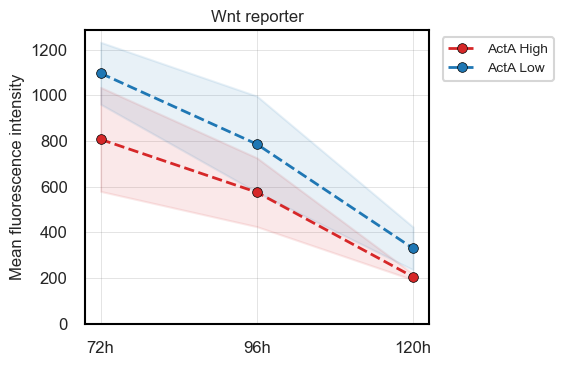

In [17]:
# numeric x positions
timepoints = np.array([72, 96, 120])

palette = {
    "ActA_Low": "#1f77b4",
    "ActA_High": "#d62728"
}

fig, ax = plt.subplots(figsize=(6,4))

for condition in wnt_pivot_mean.index:

    ax.plot(
        timepoints,
        wnt_pivot_mean.loc[condition].values,
        marker='o',
        markersize=7,
        markeredgecolor='black',
        markeredgewidth=0.5,
        linestyle='--',
        linewidth=2,
        color=palette[condition],
        label=condition.replace("_", " ")
    )

    ax.fill_between(
        timepoints,
        wnt_pivot_mean.loc[condition].values - wnt_pivot_sd.loc[condition].values,
        wnt_pivot_mean.loc[condition].values + wnt_pivot_sd.loc[condition].values,
        color=palette[condition],
        alpha=0.1
    )

# Axis formatting (same style as your template)
ax.set_title("Wnt reporter", fontsize=12)
ax.set_ylabel("Mean fluorescence intensity", fontsize=12)
ax.set_ylim(bottom=0)

ax.set_xticks(timepoints)
ax.set_xticklabels(column_order, fontsize=12)

ax.tick_params(axis='y', labelsize=12)

ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=10)
ax.grid(True, linewidth=0.5, color="gray", alpha=0.3)

for spine in ax.spines.values():
    spine.set_edgecolor("black")
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.savefig("../results/lineplot_wnt_reporter.svg", format="svg")
plt.show()


NODAL

In [18]:
# Nodal
nodal_mean = nodal_reporter.mean(axis=0)
nodal_sd = nodal_reporter.std()

In [19]:
column_order = ['72h', '96h', '120h']

# pivot mean df
df_mean = nodal_mean.reset_index()
df_mean.columns = ["condition", "value"]

df_mean["dose"] = df_mean["condition"].str.extract(r"(ActA_Low|ActA_High)")
df_mean["time"] = df_mean["condition"].str.extract(r"(\d+h)")

nodal_pivot_mean = df_mean.pivot(
    index="dose",
    columns="time",
    values="value"
).sort_index(axis=1)
nodal_pivot_mean = nodal_pivot_mean.reindex(columns=column_order)

# pivot sd df
df_sd = nodal_sd.reset_index()
df_sd.columns = ["condition", "sd"]

df_sd["dose"] = df_sd["condition"].str.extract(r"(ActA_Low|ActA_High)")
df_sd["time"] = df_sd["condition"].str.extract(r"(\d+h)")

nodal_pivot_sd = df_sd.pivot(
    index="dose",
    columns="time",
    values="sd"
).sort_index(axis=1)
nodal_pivot_sd = nodal_pivot_sd.reindex(columns=column_order)

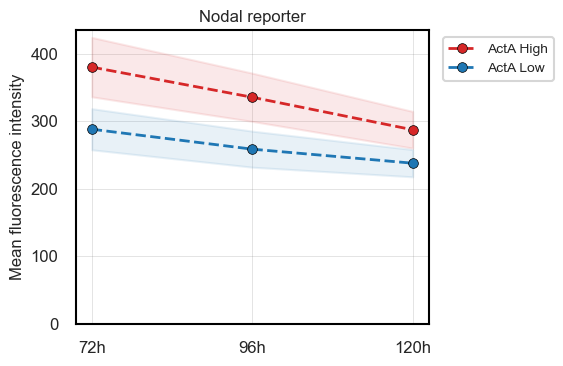

In [20]:
timepoints = np.array([72, 96, 120])
column_order = ['72h', '96h', '120h']

palette = {
    "ActA_Low": "#1f77b4",
    "ActA_High": "#d62728"
}

fig, ax = plt.subplots(figsize=(6,4))

for condition in nodal_pivot_mean.index:

    mean_vals = nodal_pivot_mean.loc[condition, column_order].values
    sd_vals   = nodal_pivot_sd.loc[condition, column_order].values

    ax.plot(
        timepoints,
        mean_vals,
        marker='o',
        markersize=7,
        markeredgecolor='black',
        markeredgewidth=0.5,
        linestyle='--',
        linewidth=2,
        color=palette[condition],
        label=condition.replace("_", " ")
    )

    ax.fill_between(
        timepoints,
        mean_vals - sd_vals,
        mean_vals + sd_vals,
        color=palette[condition],
        alpha=0.1
    )

# Axis formatting
ax.set_title("Nodal reporter", fontsize=12)
ax.set_ylabel("Mean fluorescence intensity", fontsize=12)
ax.set_ylim(bottom=0)

ax.set_xticks(timepoints)
ax.set_xticklabels(column_order, fontsize=12)

ax.tick_params(axis='y', labelsize=12)

ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=10)
ax.grid(True, linewidth=0.5, color="gray", alpha=0.3)

for spine in ax.spines.values():
    spine.set_edgecolor("black")
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.savefig("../results/lineplot_nodal_reporter.svg", format="svg")
plt.show()
